In [1]:
from Scripts.load_data import load_dataset,preprocess,encode_features,split_data
from Scripts.EDA import plot_churn_rate,plot_demographics,plot_contract_payment,plot_tenure_churn
from Scripts.segmentation import segment_customers,churn_by_segment,identify_high_value_risk
from Scripts.modeling import train_models,evaluate_models
from Scripts.evaluation import plot_roc,interpret_model
from Scripts.recommendations import estimate_impact, print_recommendations
import warnings
warnings.filterwarnings('ignore')

In [2]:
#Load and prepare data
df = load_dataset("./Data/Telco_Customer_Churn_Dataset.csv")
prep_df = preprocess(df)

In [3]:
prep_df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
prep_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [5]:
prep_df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2281.916928
std,0.368612,24.559481,30.090047,2265.270398
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,402.225000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [6]:
#display null value
prep_df.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

## Exploratory Data Analysis (EDA)

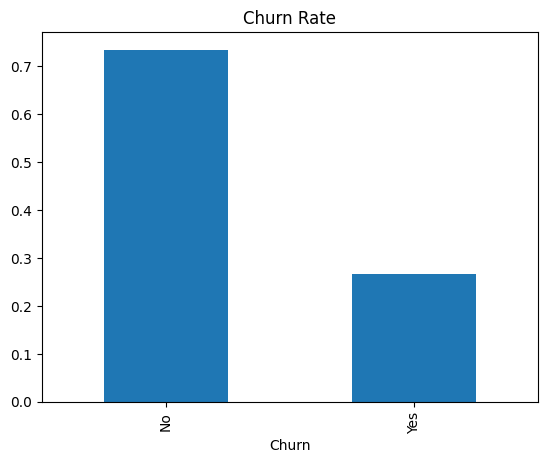

In [7]:
#Plot overall churn rate.
plot_churn_rate(prep_df)

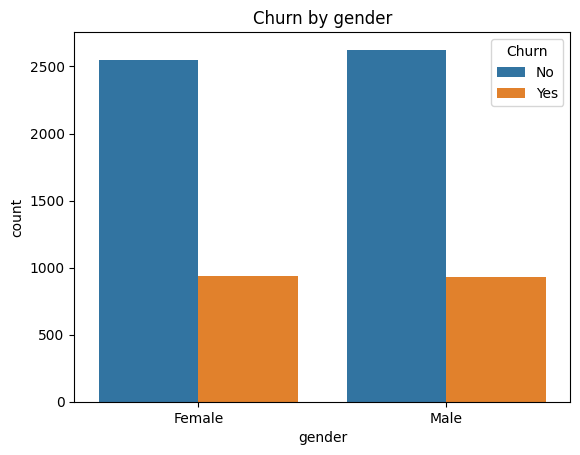

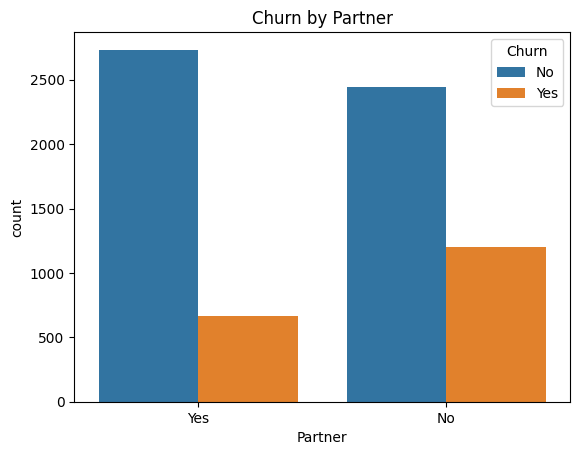

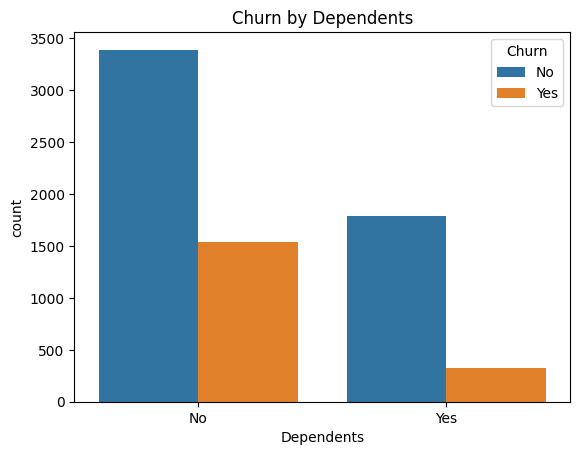

In [8]:
#Visualize churn by gender,partner, and dependents.
plot_demographics(prep_df)

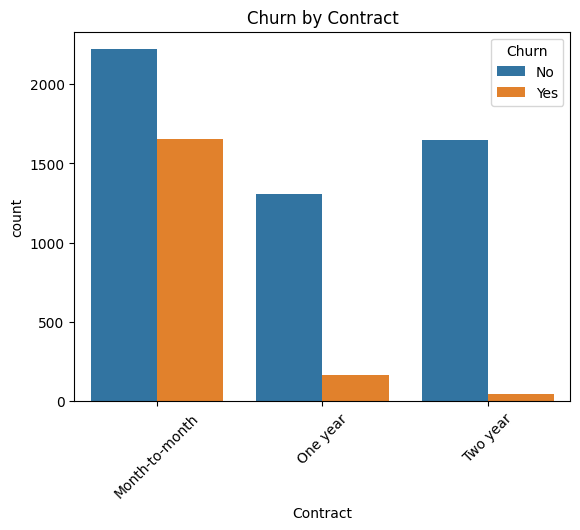

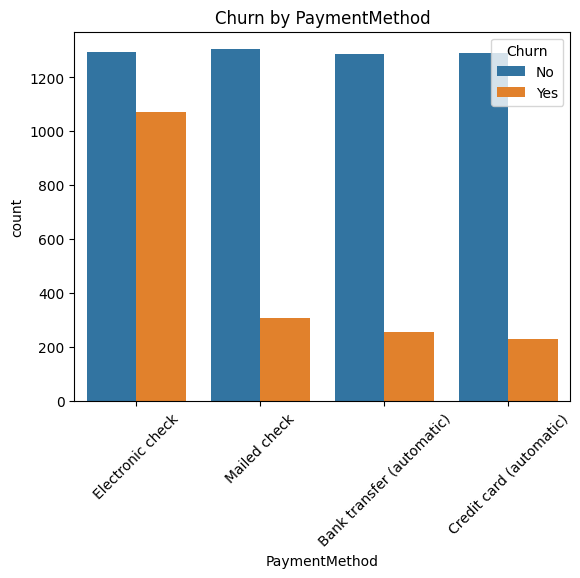

In [9]:
#Analyze tenure distribution and churn.
plot_contract_payment(prep_df)

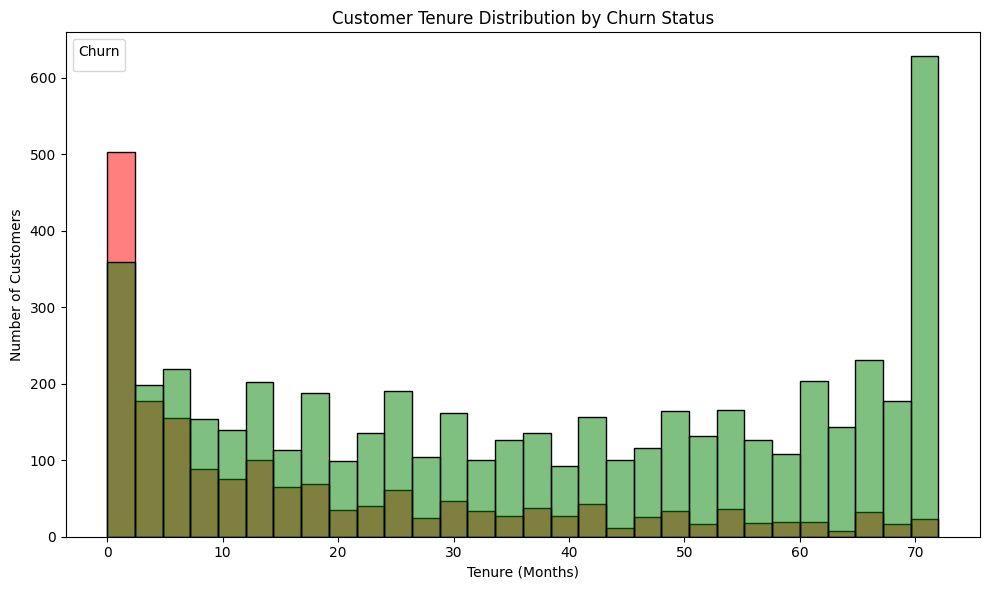

In [10]:
#Visualize churn by contract type and payment method.
plot_tenure_churn(prep_df)

## split data

In [12]:
#split data for train and test
encode_df = encode_features(prep_df)
print(encode_df)
X_train,X_test,y_train,y_test = split_data(encode_df)

      gender  SeniorCitizen  Partner  Dependents  tenure  PhoneService  \
0          1              0        1           0       1             0   
1          0              0        0           0      34             1   
2          0              0        0           0       2             1   
3          0              0        0           0      45             0   
4          1              0        0           0       2             1   
...      ...            ...      ...         ...     ...           ...   
7038       0              0        1           1      24             1   
7039       1              0        1           1      72             1   
7040       1              0        1           1      11             0   
7041       0              1        1           0       4             1   
7042       0              0        0           0      66             1   

      PaperlessBilling  MonthlyCharges  TotalCharges  Churn  ...  \
0                    1           29.85     

## Customer Segmentation

In [13]:
#Segment customers by tenure, monthly charges, and contract type.
df_segmented = segment_customers(df)
churn_by_segment(df)
high_value_risk = identify_high_value_risk(df_segmented)
print("High-value customers at risk:\n",high_value_risk.head())

Churn rate by TenureGroup:
 TenureGroup
0-12     0.476782
13-24    0.287109
25-48    0.203890
49-72    0.095132
Name: Churn, dtype: float64
Churn rate by ChargeGroup:
 ChargeGroup
Low       0.116431
Medium    0.294998
High      0.339835
Name: Churn, dtype: float64
Churn rate by Contract:
 Contract
Month-to-month    0.427097
One year          0.112695
Two year          0.028319
Name: Churn, dtype: float64
High-value customers at risk:
     tenure  MonthlyCharges        Contract
5        8           99.65  Month-to-month
8       28          104.80  Month-to-month
13      49          103.70  Month-to-month
26      47           99.35  Month-to-month
38      34          106.35  Month-to-month


## Churn Prediction Model

In [14]:
#model Training and evaluation
log_model,tree_model = train_models(X_train, y_train)
models = {"logistic Regression":log_model,"Decision Tree":tree_model}
evaluate_models(models,X_test, y_test)

logistic Regression Accuracy: 0.82
logistic Regression Precision: 0.69
logistic Regression Recall: 0.60
logistic Regression F1 Score: 0.64
Decision Tree Accuracy: 0.81
Decision Tree Precision: 0.70
Decision Tree Recall: 0.46
Decision Tree F1 Score: 0.56


## Model Evaluation and Interpretation

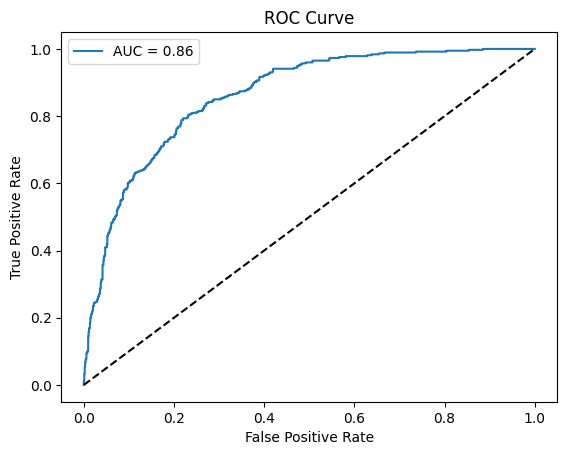

gender: 0.0522
SeniorCitizen: 0.1651
Partner: 0.0569
Dependents: -0.1621
tenure: -0.0565
PhoneService: -0.4650
PaperlessBilling: 0.3415
MonthlyCharges: 0.0027
TotalCharges: 0.0003
MultipleLines_No phone service: 0.2592
MultipleLines_Yes: 0.2254
InternetService_Fiber optic: 0.6613
InternetService_No: -0.0991
OnlineSecurity_No internet service: -0.0991
OnlineSecurity_Yes: -0.4720
OnlineBackup_No internet service: -0.0991
OnlineBackup_Yes: -0.2153
DeviceProtection_No internet service: -0.0991
DeviceProtection_Yes: -0.0611
TechSupport_No internet service: -0.0991
TechSupport_Yes: -0.3903
StreamingTV_No internet service: -0.0991
StreamingTV_Yes: 0.1315
StreamingMovies_No internet service: -0.0991
StreamingMovies_Yes: 0.2311
Contract_One year: -0.6326
Contract_Two year: -1.3896
PaymentMethod_Credit card (automatic): -0.0787
PaymentMethod_Electronic check: 0.3204
PaymentMethod_Mailed check: -0.0342


In [15]:
#Model Interpretation
plot_roc(log_model,X_test,y_test)
interpret_model(log_model,X_train.columns)

## Business Recommendations

In [16]:
#  Business Recommendations
print_recommendations()
estimate_impact(df_segmented)


📌 Business Recommendations:
- 🎯 Target customers in their first year (0–12 months) with onboarding support and loyalty incentives.
- 💰 Offer long-term contract upgrades and exclusive perks to high-value customers on month-to-month plans.
- 📞 Bundle tech support and online security services with fiber optic internet plans to reduce churn.
- 🧾 Encourage stable payment methods like credit card auto-pay and send reminders to paperless billing users.
- 🧠 Integrate churn prediction scores into CRM to trigger personalized retention workflows for at-risk customers.
- 📈 Reducing churn by 10% among high-value customers could save thousands in monthly revenue.
💰 Estimated Monthly Revenue Saved: $12103.96
